# **Malikshah Mahimi | 221A013 | 25**

### ***RL- Exp:6 (Applying dynamic programming algorithms, such as policy evaluation and policy)***

In [2]:
print("Malikshah Mahimi | 221A013")

import numpy as np
import matplotlib.pyplot as plt

Malikshah Mahimi | 221A013


## **Step 1: To create multiArmedBandit Class**

In [3]:
print("Malikshah Mahimi | 221A013")

# Step 1: To create multiArmedBandit Class

class MultiArmedBandit:
    def __init__(self, k=10):
        self.k = k
        self.q_true = np.random.normal(0, 1, k)  # True rewards for each arm
        self.best_arm = np.argmax(self.q_true)

    def pull_arm(self, arm):
        return np.random.normal(self.q_true[arm], 1)  # Reward with some noise

Malikshah Mahimi | 221A013


## **Step 2: To create agent Class**

In [4]:
print("Malikshah Mahimi | 221A013")
# Step 2: To create agent Class

class Agent:
    def __init__(self, bandit, strategy="epsilon_greedy", epsilon=0.1, c=2):
        self.bandit = bandit
        self.strategy = strategy
        self.epsilon = epsilon
        self.c = c
        self.k = bandit.k
        self.Q = np.zeros(self.k) # Estimated rewards
        self.N = np.zeros(self.k) # Number of times each arm was pulled

    def select_action(self, t):
        if self.strategy == "epsilon_greedy":
            if np.random.rand() < self.epsilon:
                return np.random.randint(self.k)  # Random action
            return np.argmax(self.Q)  # Exploit best-known action

        elif self.strategy == "ucb1":
            if 0 in self.N:  # Ensure all arms are tried at least once
                return np.argmin(self.N)
            return np.argmax(self.Q + self.c * np.sqrt(np.log(t + 1) / self.N))

        elif self.strategy == "thompson_sampling":
            samples = np.random.normal(self.Q, 1 / (self.N + 1))  # Sample from belief

    def update(self, arm, reward):
        self.N[arm] += 1
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]

Malikshah Mahimi | 221A013


## **Step 3: To create function to estimate average reward for each strategy**

In [5]:
print("Malikshah Mahimi | 221A013")

def run_strategy(k=10, steps=1000, runs=200, strategies=["epsilon_greedy", "ucb1"]):
    avg_rewards = {strategy: np.zeros(steps) for strategy in strategies}

    for strategy in strategies:
        for run in range(runs):

            bandit = MultiArmedBandit(k)
            agent = Agent(bandit, strategy=strategy)

            rewards = np.zeros(steps)
            for t in range(steps):
                action = agent.select_action(t)
                reward = bandit.pull_arm(action)
                agent.update(action, reward)
                rewards[t] = reward

            avg_rewards[strategy] += rewards / runs
    return avg_rewards

Malikshah Mahimi | 221A013


# **Step 4: To run the experiment to estimate average reward.**

In [6]:
print("Malikshah Mahimi | 221A013")

strategies = ["epsilon_greedy", "ucb1"]
results = run_strategy()

Malikshah Mahimi | 221A013


In [7]:
print("Malikshah Mahimi | 221A013")

results.keys()

Malikshah Mahimi | 221A013


dict_keys(['epsilon_greedy', 'ucb1'])

Malikshah Mahimi | 221A013


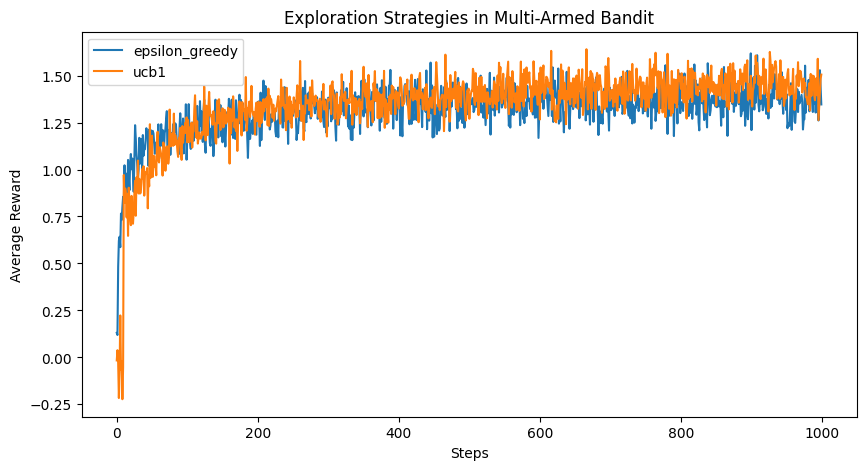

In [8]:
print("Malikshah Mahimi | 221A013")

# Plot the results
plt.figure(figsize=(10, 5))
for strategy, rewards in results.items():
    plt.plot(rewards, label=strategy)
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.legend()
plt.title("Exploration Strategies in Multi-Armed Bandit")
plt.show()


## Observations

### Initial Phase (First 100 Steps)

* Both strategies start with low rewards and improve over time.
* **UCB1** shows a faster initial learning rate, meaning it finds better arms more quickly.

### Middle Phase (100 - 500 Steps)

* **UCB1** consistently outperforms **Epsilon-Greedy** with slightly higher rewards.
* **Epsilon-Greedy** fluctuates more, as it keeps exploring randomly with probability $\epsilon$.

### Final Phase (500 - 1000 Steps)

* **UCB1** stabilizes at a slightly higher average reward.
* **Epsilon-Greedy** keeps fluctuating due to its continued exploration.
* **UCB1’s** confidence-based exploration leads to better long-term exploitation.

---

### Analysis of the Results

The reason for these observations lies in the fundamental difference between the two algorithms:

* **Epsilon-Greedy** is "static." Even if it is 99.9% sure which arm is best, it will still pull a random (likely worse) arm $\epsilon$ percent of the time. This creates a permanent "regret" floor.
* **UCB1** is "dynamic." As it pulls the best arm more often, its confidence increases and the "uncertainty bonus" for that arm shrinks. Simultaneously, the bonus for other arms grows relative to the best one until it's worth checking them again. Eventually, it converges much more cleanly because it only explores when it is actually "uncertain."